In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import random

import pandas as pd

import astropy
import astropy.table as at

from astropy.io import ascii
from astropy.table import Table

import matplotlib.cm as cm


from astropy.io.votable import parse, parse_single_table

from astropy.coordinates import SkyCoord
from dustmaps.planck import PlanckQuery
from dustmaps.sfd import SFDQuery
import astropy.units as units
import sklearn

import time
from astroquery.gaia import Gaia

In [102]:
# !wget https://www.cadc-ccda.hia-iha.nrc-cnrc.gc.ca/files/vault/PANDAS/NearbyGals/NearbyGalaxies_Jan2021_PUBLIC.fits


In [20]:
!wget https://raw.githubusercontent.com/dwarfswaves/dwarfswaves.github.io/refs/heads/main/candidate_1.csv

--2026-02-10 14:42:19--  https://raw.githubusercontent.com/dwarfswaves/dwarfswaves.github.io/refs/heads/main/candidate_1.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4479 (4.4K) [text/plain]
Saving to: ‘candidate_1.csv.1’

candidate_1.csv.1   100%[===================>]   4.37K  --.-KB/s    in 0s      

2026-02-10 14:42:20 (68.8 MB/s) - ‘candidate_1.csv.1’ saved [4479/4479]



In [104]:
nearby = at.Table.read('NearbyGalaxies_Jan2021_PUBLIC.fits')
nearby

GalaxyName,RA,Dec,EB-V,dmod,dmod+,dmod-,vh,vh+,vh-,Vmag,Vmag+,Vmag-,PA,PA+,PA-,e=1-b/a,e+,e-,muVo,muVo+,muVo-,rh,rh+,rh-,sigma_s,sigma_s+,sigma_s-,vrot_s,vrot_s+,vrot_s-,MHI,sigma_g,sigma_g+,sigma_g-,vrot_g,vrot_g+,vrot_g-,[Fe/H],feh+,feh-,F,pmra,epmra+,epmra-,pmdec,epmdec+,epmdec-,References
bytes16,bytes10,bytes11,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,bytes53
*Bootes3,13:57:12.0,26:48:0.0,0.021,18.35,0.1,0.1,197.5,3.8,3.8,12.6,0.5,0.5,90.0,999.0,999.0,0.5,999.0,999.0,31.3,0.3,0.3,999.0,999.0,999.0,14.0,3.2,3.2,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.1,0.2,0.2,2,--,--,--,--,--,--,(14)(15)(99)
*CanisMajor,7:12:35.0,-27:40:0.0,0.264,14.29,0.3,0.3,87.0,4.0,4.0,-0.1,0.8,0.8,123.0,999.0,999.0,999.0,999.0,999.0,24.0,0.6,0.6,999.0,999.0,999.0,20.0,3.0,3.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-0.5,0.2,0.2,4,--,--,--,--,--,--,(1)(2)(95)(176)
*Cetus2,1:17:52.8,-17:25:12.0,0.02,17.1,0.1,0.1,999.0,999.0,999.0,17.4,0.7,0.7,999.0,999.0,999.0,999.0,999.0,999.0,28.55,1.2,1.2,1.9,1.0,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-1.28,0.07,0.07,5,2.84,0.05,0.07,0.46,0.06,0.07,(232)(260)(266)(267)
*Columba1,5:31:26.4,-28:1:48.0,0.025,21.3,0.22,0.22,153.7,5.0,4.8,16.8,0.2,0.2,999.0,999.0,999.0,999.0,999.0,999.0,27.95,0.7,0.7,1.9,0.5,0.4,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,9,0.19,0.06,0.06,-0.36,0.06,0.06,(232)(248)(266)(267)
*Draco2,15:52:47.6,64:33:55.0,0.018,16.67,0.05,0.05,-342.5,1.1,1.2,14.0,0.8,0.8,76.0,22.0,32.0,0.23,0.15,0.15,25.62,1.3,1.3,3.0,0.7,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.7,0.1,0.1,5,1.08,0.07,0.07,0.91,0.08,0.08,(225)(259)(266)(267)
*Eridanus3,2:22:45.5,-52:17:1.0,0.025,19.7,0.2,0.2,999.0,999.0,999.0,17.33,0.86,0.86,62.0,11.0,11.0,0.32,0.13,0.13,22.84,4.28,2.13,0.29,0.23,0.23,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,9,1.08,0.14,0.45,-0.49,0.17,0.13,(226)(227)(255)(266)(267)
*Grus1,22:56:42.4,-50:9:48.0,0.008,20.4,0.2,0.2,-140.5,2.4,1.6,16.93,0.59,0.59,11.0,32.0,32.0,0.54,0.26,0.26,26.86,1.77,1.35,2.08,0.87,0.87,9.8,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-1.42,0.55,0.42,2,0.07,0.05,0.05,-0.29,0.06,0.07,(226)(252)(255)(266)(267)
*Grus2,22:4:4.8,-46:26:24.0,0.016,18.62,0.21,0.21,-110.0,0.5,0.5,14.7,0.2,0.2,999.0,999.0,999.0,999.0,999.0,999.0,28.35,0.7,0.7,6.0,0.9,0.5,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.51,0.11,0.11,3,0.38,0.03,0.03,-1.46,0.04,0.04,(232)(262)(266)(267)
*Horologium1,2:55:31.7,-54:7:8.0,0.014,19.5,0.2,0.2,112.8,2.5,2.6,15.95,0.56,0.56,50.0,26.0,26.0,0.31,0.16,0.16,26.28,1.1,0.99,1.54,0.34,0.34,4.9,2.8,0.9,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,999.0,-2.76,0.1,0.1,2,0.82,0.03,0.03,-0.61,0.03,0.03,(226)(227)(254)(255)(266)(267)


In [25]:
!wget https://raw.githubusercontent.com/dwarfswaves/dwarfswaves.github.io/refs/heads/main/candidate_2.csv

--2026-02-10 14:51:36--  https://raw.githubusercontent.com/dwarfswaves/dwarfswaves.github.io/refs/heads/main/candidate_2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1504 (1.5K) [text/plain]
Saving to: ‘candidate_2.csv’

candidate_2.csv     100%[===================>]   1.47K  --.-KB/s    in 0s      

2026-02-10 14:51:36 (28.5 MB/s) - ‘candidate_2.csv’ saved [1504/1504]



In [46]:
candi_wavelet = pd.read_csv('candidate_2.csv')
candi_wavelet

,Unnamed: 0,source_id,dec,ra,pmra,pmdec,pmra_error,pmdec_error,parallax,parallax_error,...,bp_g,bp_rp,phot_g_mean_flux,phot_g_mean_flux_error,phot_bp_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_rp_mean_mag,phot_rp_mean_flux,phot_rp_mean_flux_error
0,351,3.694700e+18,-1.778258,185.911563,-1.856842,-1.587827,0.650409,0.346072,0.364194,0.334638,...,0.275600,0.861231,620.163923,1.358747,18.982700,352.756637,11.813906,18.121470,453.085400,6.235875
1,2048,3.694690e+18,-1.820663,186.065248,-2.359703,-1.639413,0.252295,0.144184,-0.340064,0.134653,...,0.167730,0.554670,2694.421252,40.112147,17.279932,1692.710689,88.120814,16.725262,1639.318047,57.702462
2,2703,3.694700e+18,-1.757881,185.976780,-1.839716,-1.458793,0.231413,0.136968,-0.028396,0.123043,...,0.483509,1.140743,3294.261366,2.935275,17.377480,1547.260737,7.914949,16.236736,2570.830282,8.658995
3,2709,3.694700e+18,-1.769745,185.950939,-1.794859,-1.570040,1.559956,0.718909,-0.148532,0.819093,...,0.166574,0.714191,207.757801,1.046456,20.061047,130.658285,6.078974,19.346855,146.563649,6.314567
4,2846,3.694690e+18,-1.785465,186.016646,-1.818842,-1.377200,2.051190,1.076516,1.905339,1.091935,...,0.013329,0.666397,126.422894,0.868855,20.447130,91.559412,5.825455,19.780733,98.282253,6.180286


SELECT ra, dec, pmra, pmdec, phot_g_mean_mag, parallax FROM gaiadr3.gaia_source WHERE (ra < 188.9115631 AND ra > 182.9115631 AND dec <  1.221741996 AND dec > -4.778258004 AND pmra < 5 AND pmra > -5 AND pmdec > -5 AND pmdec < 5 AND phot_g_mean_mag < 20 AND parallax IS NOT NULL AND parallax - parallax_error * 3 < 0.0 AND ruwe < 1.4 AND ebpminrp_gspphot IS NOT NULL)
INFO: Query finished. [astroquery.utils.tap.core]
1.4805457592010498


Text(0, 0.5, 'Dec')

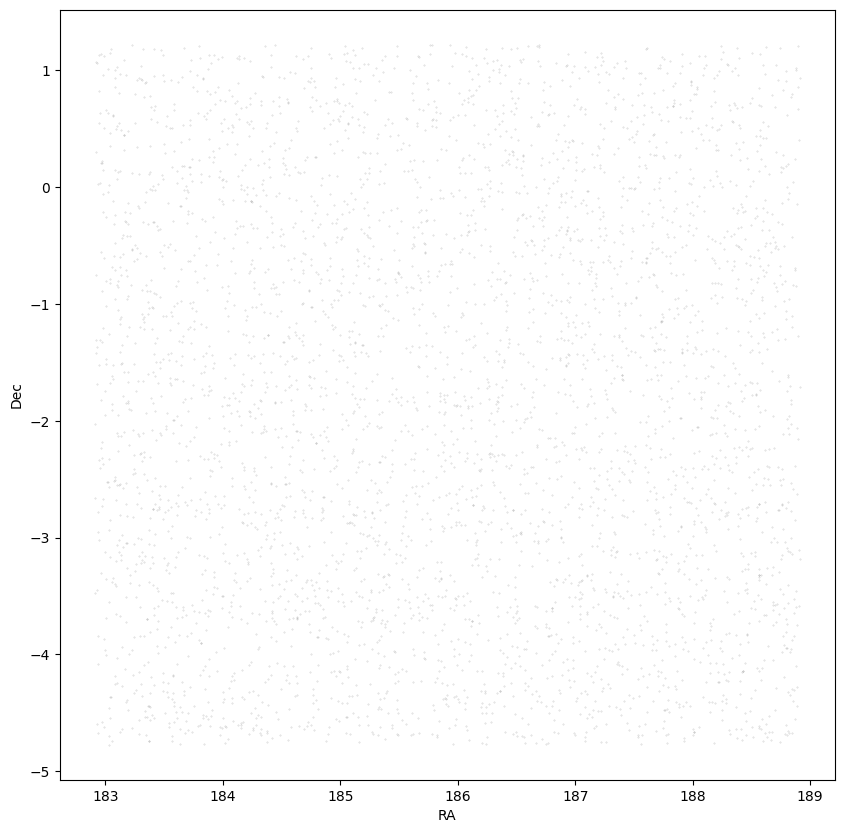

In [111]:
## I am not too convinced that you can detect those candidates from the wavelet paper, I'm confused there's so few members?
## worth a shot ig

### square select

center_ra, center_dec = candi_wavelet['ra'][0], candi_wavelet['dec'][0]
degsep = 3 # Up to you? Might depend on the type of objects and crowdedness 
minmag = 20 # Maybe this should be modified?

## I have to retrieve in my note the additional cuts we might want to apply

query = "SELECT ra, dec, pmra, pmdec, phot_g_mean_mag, parallax FROM gaiadr3.gaia_source \
WHERE (ra < {} \
AND ra > {} \
AND dec <  {} \
AND dec > {} \
AND pmra < 5 \
AND pmra > -5 \
AND pmdec > -5 \
AND pmdec < 5 \
AND phot_g_mean_mag < {} \
AND parallax IS NOT NULL \
AND parallax - parallax_error * 3 < 0.0 \
AND ruwe < 1.4 \
AND ebpminrp_gspphot IS NOT NULL)".format(center_ra + degsep, center_ra - degsep, center_dec + degsep, center_dec - degsep,
                                         minmag)

print(query)
t= time.time()
job = Gaia.launch_job_async(query)

r = job.get_results()
print(time.time()-t)

plt.figure(figsize=(10,10))

plt.scatter(r['ra'], r['dec'], s=.1, alpha=.2, c='k', rasterized=True)
plt.xlabel('RA')
plt.ylabel('Dec')

## Some known dwarfs galaxies 

In [58]:
# https://iopscience.iop.org/article/10.3847/1538-4357/ab7eb9 
# Confirmed and candidates:
# (Classifications are: (1) unconfirmed systems, (2) probable star clusters, (3) probable dwarfs, (4) kinematically confirmed dwarfs)
!wget https://content.cld.iop.org/journals/0004-637X/893/1/47/revision1/apjab7eb9t2_mrt.txt 
# this paper " recovered 18 out of 21 confirmed and candidate satellite galaxies in the DES footprint ; [..]
# recovered 20 of the 32 confirmed and candidate satellite galaxies known to reside in the PS1 DR1 footprint. 
# The lower recovery rate in PS1 is expected since many of the satellites in the PS1 footprint were discovered with significantly 
# deeper data. "

--2026-02-11 12:44:52--  https://content.cld.iop.org/journals/0004-637X/893/1/47/revision1/apjab7eb9t2_mrt.txt
Resolving content.cld.iop.org (content.cld.iop.org)... 108.157.194.98, 108.157.194.74, 108.157.194.31, ...
Connecting to content.cld.iop.org (content.cld.iop.org)|108.157.194.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9578 (9.4K) [text/plain]
Saving to: ‘apjab7eb9t2_mrt.txt.1’

apjab7eb9t2_mrt.txt 100%[===================>]   9.35K  --.-KB/s    in 0s      

2026-02-11 12:44:52 (237 MB/s) - ‘apjab7eb9t2_mrt.txt.1’ saved [9578/9578]



In [60]:
dwarfs =ascii.read('apjab7eb9t2_mrt.txt')

In [55]:
!cat apjab7eb9t2_mrt.txt

Title: Milky Way Satellite Census - I. The Observational Selection Function 
       for Milky Way Satellites in DES Y3 and Pan-STARRS DR1 
Authors: Drlica-Wagner A., Bechtol K., Mau S., McNanna M., Nadler E.O., 
         Pace A.B., Li T.S., Pieres A., Rozo E., Simon J.D., Walker A.R., 
         Wechsler R.H., Abbott T.M.C., Allam S., Annis J., Bertin E., 
         Brooks D., Burke D.L., Rosell A.C., Kind M.C., Carretero J., 
         Costanzi M., da Costa L.N., Vicente J.D., Desai S., Diehl H.T., 
         Doel P., Eifler T.F., Everett S., Flaugher B., Frieman J., 
         Garcia-Bellido J., Gaztanaga E., Gruen D., Gruendl R.A., Gschwend J.,
         Gutierrez G., Honscheid K., James D.J., Krause E., Kuehn K., 
         Kuropatkin N., Lahav O., Maia M.A.G., Marshall J.L., Melchior P., 
         Menanteau F., Miquel R., Palmese A., Plazas A.A., Sanchez E., 
         Scarpine V., Schubnell M., Serrano S., Sevilla-Noarbe I., 
         Smith M., Suchyta E., Tarle G. 
Table: Confirmed and 

In [64]:
dwarfs

Name,Survey,Class,RAdeg,DEdeg,m-M,ah,l_e,e,D,r1/2,VMag,Ref
,,,deg,deg,mag,arcmin,,,kpc,pc,mag,
str17,str8,int64,float64,float64,float64,float64,str1,float64,int64,int64,float64,str6
Antlia II,--,4,143.8868,-36.7673,20.6,76.2,--,0.38,132,2301,-9.03,1
Aquarius II,PS1,4,338.4813,-9.3274,20.2,5.1,--,0.39,108,125,-4.4,2
Bootes I,PS1,4,210.02,14.5135,19.1,9.97,--,0.3,66,160,-6.02,3
Bootes II,PS1,4,209.5141,12.8553,18.1,3.17,--,0.25,42,33,-2.94,3
Bootes III,PS1,4,209.3,26.8,18.4,30.0,--,0.5,47,289,-5.75,4
Bootes IV,PS1,3,233.689,43.726,21.6,7.6,--,0.64,209,277,-4.53,5
Canes Venatici I,PS1,4,202.0091,33.5521,21.7,7.12,--,0.44,218,338,-8.8,3
Canes Venatici II,PS1,4,194.2927,34.3226,21.0,1.52,--,0.4,160,55,-5.17,3


In [105]:
fornaxid = np.where(dwarfs['Name']=='Fornax')[0][0]
dwarfs[fornaxid]

Name,Survey,Class,RAdeg,DEdeg,m-M,ah,l_e,e,D,r1/2,VMag,Ref
,,,deg,deg,mag,arcmin,,,kpc,pc,mag,
str17,str8,int64,float64,float64,float64,float64,str1,float64,int64,int64,float64,str6
Fornax,DES,4,39.9583,-34.4997,20.8,19.6,--,0.29,147,707,-13.46,3; 14


In [112]:
# ### square select

# ##Reduce the amount of features we get

# center_ra, center_dec = dwarfs['RAdeg'][fornaxid], dwarfs['DEdeg'][fornaxid]
# degsep = 3 # Up to you? Might depend on the type of objects and crowdedness 
# minmag = 20 # Maybe this should be modified?

# ## I have to retrieve in my note the additional cuts we might want to apply

# query = "SELECT ra, dec, pmra, pmdec, phot_g_mean_mag, parallax FROM gaiadr3.gaia_source \
# WHERE (ra < {} \
# AND ra > {} \
# AND dec <  {} \
# AND dec > {} \
# AND phot_g_mean_mag < {} \
# AND parallax IS NOT NULL \
# AND parallax_over_error > 10.0  \
# AND ruwe < 1.4 \
# AND ebpminrp_gspphot IS NOT NULL)".format(center_ra + degsep, center_ra - degsep, center_dec + degsep, center_dec - degsep,
#                                          minmag)

# print(query)
# t= time.time()
# job = Gaia.launch_job_async(query)

# r = job.get_results()
# print(time.time()-t)
# print(len(r))

In [ ]:

# plt.figure(figsize=(10,10))

# plt.scatter(r['ra'], r['dec'], s=.5, alpha=.2, c='k', rasterized=True)
# plt.xlabel('RA')
# plt.ylabel('Dec')

### QUERY WITH THE PARALLAX CUT AS WAVELET

In [108]:
### square select

##Reduce the amount of features we get

center_ra, center_dec = dwarfs['RAdeg'][fornaxid], dwarfs['DEdeg'][fornaxid]
degsep = 3 # Up to you? Might depend on the type of objects and crowdedness 
minmag = 20 # Maybe this should be modified?

## I have to retrieve in my note the additional cuts we might want to apply

## The cut in pmra/pmdec follow the wavelet paper; I don't know if we want to do it
## The cut in parallax - parallax_error is also following the wavelet paper and says it's to remove foreground stars but 
## I'd be in favor of asknig around the best way to do that? Or we keep it consistent with them like that

query = "SELECT ra, dec, pmra, pmdec, phot_g_mean_mag, parallax FROM gaiadr3.gaia_source \
WHERE (ra < {} \
AND ra > {} \
AND dec <  {} \
AND dec > {} \
AND pmra < 5 \
AND pmra > -5 \
AND pmdec > -5 \
AND pmdec < 5 \
AND phot_g_mean_mag < {} \
AND parallax IS NOT NULL \
AND parallax - parallax_error * 3 < 0.0  \
AND ruwe < 1.4 \
AND ebpminrp_gspphot IS NOT NULL)".format(center_ra + degsep, center_ra - degsep, center_dec + degsep, center_dec - degsep,
                                         minmag)

print(query)
t= time.time()
job = Gaia.launch_job_async(query)

r = job.get_results()
print(time.time()-t)
print(len(r))

SELECT ra, dec, pmra, pmdec, phot_g_mean_mag, parallax FROM gaiadr3.gaia_source WHERE (ra < 42.9583 AND ra > 36.9583 AND dec <  -31.499699999999997 AND dec > -37.4997 AND phot_g_mean_mag < 20 AND parallax IS NOT NULL AND parallax - parallax_error * 3 < 0.0  AND ruwe < 1.4 AND ebpminrp_gspphot IS NOT NULL)
INFO: Query finished. [astroquery.utils.tap.core]
2.5888729095458984
7469


Text(0, 0.5, 'Dec')

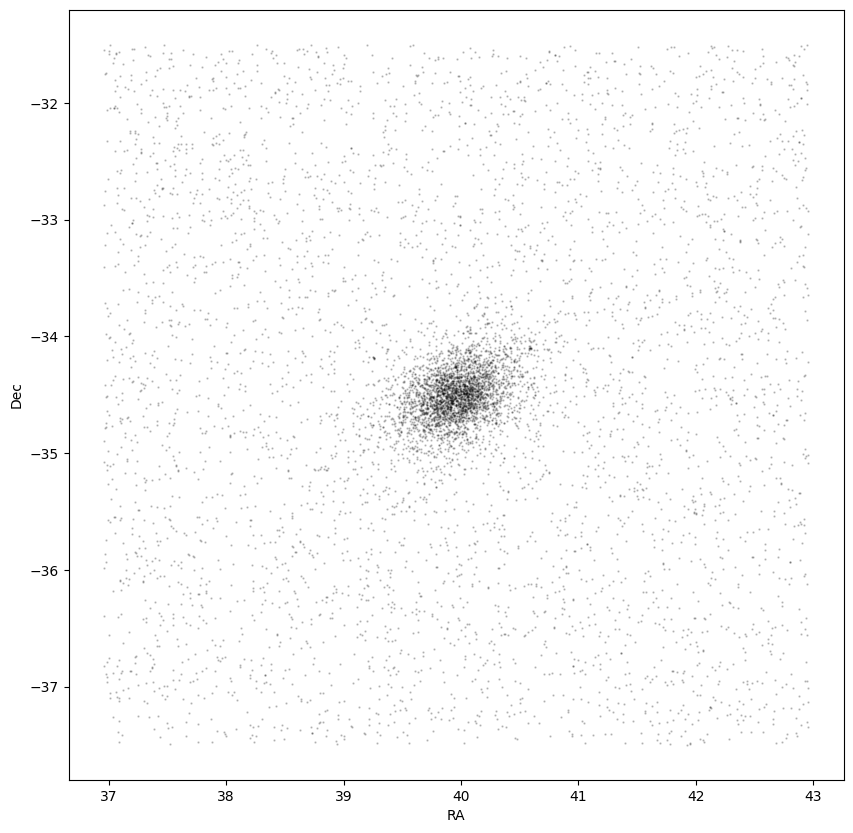

In [109]:

plt.figure(figsize=(10,10))

plt.scatter(r['ra'], r['dec'], s=.5, alpha=.2, c='k', rasterized=True)
plt.xlabel('RA')
plt.ylabel('Dec')

In [88]:
from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord



In [100]:
# Search for catalogs mentioning your dwarf galaxy
v = Vizier(columns=['**'], row_limit=-1)
catalogs = Vizier.find_catalogs('Carina gaia')

catalogs

OrderedDict([('I/324', </>),
             ('I/337', </>),
             ('I/345', </>),
             ('I/347', </>),
             ('I/350', </>),
             ('I/352', </>),
             ('I/355', </>),
             ('I/356', </>),
             ('I/357', </>),
             ('I/358', </>),
             ('I/359', </>),
             ('I/360', </>),
             ('I/361', </>),
             ('IV/36', </>),
             ('VI/137', </>),
             ('VI/145', </>),
             ('J/A+A/523/A48', </>),
             ('J/A+A/674/A25', </>)])

In [101]:
# Once you identify the right catalog ID (e.g., 'J/ApJ/...')
result = v.get_catalogs(catalogs)
result


KeyboardInterrupt



In [99]:
result[0]

recno,HJD,Weight,RV(A),RV(B),res(A),res(B)
,d,,km / s,km / s,km / s,km / s
int32,float64,float32,float32,float32,float32,float32
1,2451144.83060,1.0,257.4,-279.8,-3.0,-2.0
2,2451145.84399,0.0,25.0,13.2,28.5,8.8
3,2451146.86755,1.0,-256.0,284.5,5.2,4.5
4,2451147.86649,0.0,-1.4,48.9,34.9,9.4
5,2451148.80902,1.0,247.7,-278.5,12.1,-1.4
6,2451149.87170,0.0,106.7,66.2,55.4,120.4
7,2451150.83746,1.0,-262.2,276.5,0.5,-5.1
8,2451152.73657,1.0,240.0,-275.1,-2.8,-16.1


In [ ]:
### Other option is a cone search but somehow it is super slow in some instances? 

# center_ra, center_dec = 76.16, -15.36
# degsep = 3

# ## This selects ALL features from gaia lite which is overkill
# query = "SELECT *,  DISTANCE( \
#    POINT({}, {}), \
#    POINT(ra, dec)) AS ang_sep \
# FROM gaiadr3.gaia_source_lite \
# WHERE 1 = CONTAINS( \
#    POINT({}, {}), \
#    CIRCLE(ra, dec, {})) \
# AND phot_g_mean_mag < 20 \
# AND parallax IS NOT NULL \
# AND parallax_over_error > 10.0  \
# AND ruwe < 1.4 \
# AND ebpminrp_gspphot IS NOT NULL".format(center_ra, center_dec, center_ra, center_dec, degsep)
# print(query)

# t= time.time()
# job = Gaia.launch_job_async(query)

# r = job.get_results()
# print(time.time()-t)